# **Применение моделей машинного обучения для предсказания ССЗ**

In [1]:
#Загрузка библиотек
import pandas as pd                  # Импорт библиотеки pandas для работы с табличными данными (DataFrame)
import numpy as np                   # Импорт библиотеки numpy для работы с массивами и числовыми операциями
import seaborn as sns                # Импорт библиотеки seaborn для создания красивых и информативных визуализаций данных
from matplotlib import pyplot as plt # Импорт функции pyplot из библиотеки matplotlib для создания графиков и визуализаций


## **1.Предобработка данных**

In [2]:
#Чтение данных
from google.colab import drive
drive.mount('/content/drive')
cvd_data_train = pd.read_csv("./drive/MyDrive/Глубокое обучение/data/train.csv", sep=',')
cvd_data_test = pd.read_csv("./drive/MyDrive/Глубокое обучение/data/test.csv", sep=',')
#Просмотр загруженных датасетов
display(cvd_data_train.head())
display(cvd_data_test.head())

Mounted at /content/drive


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,600000,53.963191,1,4.000000,136.940829,236.862814,0,2,143.961525,1,0.711100,1,2,7
1,600001,49.621479,1,4.000000,122.024651,226.593019,0,2,112.220874,1,0.000000,1,1,7
2,600002,36.933893,1,1.300924,127.585643,351.061046,0,0,177.945922,0,0.313078,1,0,7
3,600003,54.884588,1,3.000000,124.876745,250.370530,0,0,153.176526,0,0.308277,1,1,7
4,600004,71.016392,0,1.746972,120.922600,210.979710,0,0,164.573122,0,1.021370,1,1,3


In [3]:
#Смртрим основную информацию про тренировочные данные
cvd_data_train.info()
#датасет содержит 600000 строк и 15 столбцов, из которых только 6 имеют тип данных
#float64, а остальные int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

### **Описание столбцов из тренировочного датасета:**

-ID;

-age (возраст);

-sex (пол);

-сhest (боль в груди от 1 до 4);

-resting_blood_pressure (артериальное давление в состоянии покоя);

-serum_cholestoral (уровень холестерина в крови mg/dl);

-fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl));

-maximum_heart_rate_achieved (максимальная частота сердечных сокращений);

-exercise_induced_angina (стенокардия при нагрузке);

-oldpeak (депрессия ST-сегмента);

-slope (наклон пикового сегмента ST при физической нагрузке);

-number_of_major_vessels (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);

-resting_electrocardiographic_results (результаты электрокардиографических исследований в покое 0, 1, 2);

-thal (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект);

-class (0-нет сердечно-сосудистого заболевания, 1-есть)

In [4]:
#Подсчитаем количество значений всех признаков датасета, включая пропущенные
for col in cvd_data_train.columns:
    print(f'Признак:  {cvd_data_train[col].value_counts(dropna=False)}')
    print()

#данные выглядят адекватно, но возраст, давление, холестерин и ЧСС - это целочисленные
#значения в мед. практике, но в датасете у них тип float, нужно это исправить.
#кроме того, значения в столбце талассемии можно заменить на 0-нет и 1-есть,
#столбец боли за грудиной должен быть целочисленным, т.к. это категориальный признак,
#указывающий на вид боли, для удобства шкалу можно изменить на 0-3 замето 1-4.
#аналогичную замену стоит провести в столбце slope с 1-3 на 0-2.

Признак:  ID
599983    1
599982    1
599981    1
599980    1
599979    1
         ..
4         1
3         1
2         1
1         1
0         1
Name: count, Length: 600000, dtype: int64

Признак:  age
54.847012    3
46.186438    3
58.547094    3
58.856141    3
54.640389    3
            ..
50.041141    1
44.688120    1
68.763590    1
68.239245    1
51.689607    1
Name: count, Length: 594106, dtype: int64

Признак:  sex
1    406468
0    193532
Name: count, dtype: int64

Признак:  chest
4.000000    285344
3.000000    176173
1.782514         4
1.730036         4
1.945328         4
             ...  
1.276876         1
1.493459         1
1.489957         1
1.501289         1
1.797030         1
Name: count, Length: 133009, dtype: int64

Признак:  resting_blood_pressure
120.185103    3
138.412515    3
120.154046    3
140.754344    3
121.189015    3
             ..
121.110240    1
121.724050    1
130.248868    1
141.637707    1
129.397204    1
Name: count, Length: 596241, dtype: int64

Призн

In [5]:
#Проверяем наличие пропусков
#Находим пустые значения и считаем их сумму
cvd_null_train = cvd_data_train.isnull().sum()
#Сортируем значения по убыванию
cvd_null_train_count = cvd_null_train.sort_values(ascending=False)
#Просматриваем series с ними
print(cvd_null_train_count)
#пропусков нет

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64


In [6]:
#Смртрим основную информацию про тестовые данные
cvd_data_test.info()
#датасет содержит 400000 записей и 14 столбцов, из которых только 6 имеют тип данных float64, а остальные int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               400000 non-null  float64
 11  

### **Описание столбцов из тестового датасета:**

-ID;

-age (возраст);

-sex (пол);

-сhest (боль в груди от 1 до 4);

-resting_blood_pressure (артериальное давление в состоянии покоя);

-serum_cholestoral (уровень холестерина в крови mg/dl);

-fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl));

-maximum_heart_rate_achieved (максимальная частота сердечных сокращений);

-exercise_induced_angina (стенокардия при нагрузке);

-oldpeak (депрессия ST-сегмента);

-slope (наклон пикового сегмента ST при физической нагрузке);

-number_of_major_vessels (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);

-resting_electrocardiographic_results (результаты электрокардиографических исследований в покое 0, 1, 2);

-thal (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект)

In [7]:
#Подсчитаем количество значений всех признаков датасета, включая пропущенные
for col in cvd_data_test.columns:
    print(f'Признак:  {cvd_data_test[col].value_counts(dropna=False)}')
    print()

#вывод аналогичный тренировочным данным

Признак:  ID
999983    1
999982    1
999981    1
999980    1
999979    1
         ..
600004    1
600003    1
600002    1
600001    1
600000    1
Name: count, Length: 400000, dtype: int64

Признак:  age
43.162946    3
49.366324    3
55.599501    3
50.060007    3
57.635933    3
            ..
48.771892    1
55.884132    1
54.182166    1
54.409916    1
52.545461    1
Name: count, Length: 397391, dtype: int64

Признак:  sex
1    270743
0    129257
Name: count, dtype: int64

Признак:  chest
4.000000    190325
3.000000    116866
1.588268         3
1.510257         3
1.589560         3
             ...  
1.447645         1
1.285747         1
1.572915         1
1.363473         1
1.786621         1
Name: count, Length: 90257, dtype: int64

Признак:  resting_blood_pressure
119.500663    3
139.800837    3
128.508529    3
121.582308    3
139.483754    3
             ..
137.707642    1
110.039686    1
123.937407    1
121.857770    1
136.968123    1
Name: count, Length: 398274, dtype: int64

Призна

In [8]:
#Проверяем наличие пропусков
#Находим пустые значения и считаем их сумму
cvd_null_test = cvd_data_test.isnull().sum()
#Сортируем значения по убыванию
cvd_null_test_count = cvd_null_test.sort_values(ascending=False)
#Просматриваем series с ними
print(cvd_null_test_count)
#пропусков нет

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
dtype: int64


In [9]:
#Посмотрим основные статистики по тестовым данным
cvd_data_test.describe().round(2).T
#по большей части все в порядке, за исключением отрицательного min значения в стоблце
#chest, т.к. нам известно, что боль в груди оценивается от 1 до 4, а отрицательное
#значение min в столбце oldpeak вполне возможно, т.к. это депрессия сегмента ST

,count,mean,std,min,25%,50%,75%,max
ID,400000.0,799999.50,115470.20,600000.00,699999.75,799999.50,899999.25,999999.00
age,400000.0,54.41,9.10,27.50,48.02,55.13,60.67,80.75
sex,400000.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
chest,400000.0,3.17,0.95,-0.34,3.00,3.00,4.00,4.00
resting_blood_pressure,400000.0,131.37,17.86,85.83,119.94,129.74,139.94,212.30
serum_cholestoral,400000.0,249.59,51.72,94.96,216.46,244.27,274.36,527.71
fasting_blood_sugar,400000.0,0.15,0.36,0.00,0.00,0.00,0.00,1.00
resting_electrocardiographic_results,400000.0,1.03,0.99,0.00,0.00,2.00,2.00,2.00
maximum_heart_rate_achieved,400000.0,149.66,23.07,58.96,135.82,153.34,165.22,207.41
exercise_induced_angina,400000.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


In [10]:
#Ищем значения в столбце chest, которые отличны от 1,2,3,4
condition = ~cvd_data_test['chest'].isin([1, 2, 3, 4])
if condition.any():
    print('Есть строки')
    #print('Индексы этих строк:')
    index_test = cvd_data_test.index[condition].tolist()
    #print(index_test)
else:
    print('Все строки корректны')


Есть строки
Индексы этих строк:


In [11]:
cvd_test_work = cvd_data_test.copy()
#Выполняем замену в столбце chest
#Где значения больше 1, просто округляем до целого, а где меньше 1-заменяем на 1
for i in index_test:
    if cvd_test_work.loc[i, 'chest'] > 1:
        cvd_test_work.loc[i, 'chest'] = round(cvd_test_work.loc[i, 'chest'])
    else:
        cvd_test_work.loc[i, 'chest'] = 1

In [12]:
condition = ~cvd_test_work['chest'].isin([1, 2, 3, 4])
if condition.any():
    print('Есть строки')
    #print('Индексы этих строк:')
    index_test_work = cvd_test_work.index[condition].tolist()
    #print(index_test_work)
else:
    print('Все строки корректны')


Все строки корректны


In [13]:
#Аналогично посмотрим основные статистики по тренировочным данным
cvd_data_train.describe().round(2).T
#вывод аналогичен тестовым данным
#в столбце ID достаточно большие показатели, что вполне логично, этот столбик для ML будет удален

,count,mean,std,min,25%,50%,75%,max
ID,600000.0,299999.50,173205.23,0.00,149999.75,299999.50,449999.25,599999.00
age,600000.0,54.43,9.09,26.06,48.08,55.13,60.66,79.59
sex,600000.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
chest,600000.0,3.17,0.95,-0.54,3.00,3.00,4.00,4.00
resting_blood_pressure,600000.0,131.34,17.84,82.92,119.92,129.73,139.92,209.67
serum_cholestoral,600000.0,249.59,51.70,98.33,216.48,244.23,274.35,527.76
fasting_blood_sugar,600000.0,0.15,0.36,0.00,0.00,0.00,0.00,1.00
resting_electrocardiographic_results,600000.0,1.02,0.99,0.00,0.00,2.00,2.00,2.00
maximum_heart_rate_achieved,600000.0,149.59,23.07,61.84,135.70,153.22,165.17,208.74
exercise_induced_angina,600000.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


In [14]:
#Выполняем проверку и замену аналогично тестовым данным
condition = ~cvd_data_train['chest'].isin([1, 2, 3, 4])
if condition.any():
    print('Есть строки')
    #print('Индексы этих строк:')
    index_train = cvd_data_train.index[condition].tolist()
    #print(index_train)
else:
    print('Все строки корректны')

Есть строки


In [15]:
cvd_train_work = cvd_data_train.copy()

In [16]:
for i in index_train:
    if cvd_train_work.loc[i, 'chest'] > 1:
        cvd_train_work.loc[i, 'chest'] = round(cvd_train_work.loc[i, 'chest'])
    else:
        cvd_train_work.loc[i, 'chest'] = 1

In [17]:
condition = ~cvd_train_work['chest'].isin([1, 2, 3, 4])
if condition.any():
    print('Есть строки')
    #print('Индексы этих строк:')
    index_train_work = cvd_train_work.index[condition].tolist()
    #print(index_train_work)
else:
    print('Все строки корректны')

Все строки корректны


In [18]:
#Рассмотрим количество уникальных значений по столбцам в тренировочном наборе
cvd_data_train.nunique()
#все значения в столбце ID уникальные, т.к. это идентификатор пациента, в дальнейшем столбец будет удален
#в сотальном все в порядке
#т.к. все ID уникальные (600000 строк и 600000 уникальных значений), то нет дублирующихся записей

,0
ID,600000
age,594106
sex,2
chest,133009
resting_blood_pressure,596241
serum_cholestoral,598797
fasting_blood_sugar,2
resting_electrocardiographic_results,3
maximum_heart_rate_achieved,597583
exercise_induced_angina,2


In [19]:
#Рассмотрим количество уникальных значений по столбцам в тестовом наборе
cvd_data_test.nunique()
#аналогично предыдущему пункту

,0
ID,400000
age,397391
sex,2
chest,90257
resting_blood_pressure,398274
serum_cholestoral,399436
fasting_blood_sugar,2
resting_electrocardiographic_results,3
maximum_heart_rate_achieved,398888
exercise_induced_angina,2


In [20]:
#Меняем тип данных в столбцах, где должны быть целые значения
for col in ['chest', 'resting_blood_pressure', 'maximum_heart_rate_achieved', 'age', 'serum_cholestoral']:
    cvd_train_work[col] = cvd_train_work[col].astype(int)
    cvd_test_work[col] = cvd_test_work[col].astype(int)

#Округляем значение депрессии сегмента ST для наглядности
cvd_train_work['oldpeak'] = cvd_train_work['oldpeak'].round(2)
cvd_test_work['oldpeak'] = cvd_test_work['oldpeak'].round(2)

In [21]:
cvd_train_work.head(20)

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49,0,4,162,181,0,0,148,1,0.94,2,0,3,1
1,1,53,1,2,130,276,0,2,152,0,0.12,2,0,3,0
2,2,49,1,4,146,223,1,2,102,1,1.62,2,2,7,1
3,3,58,1,4,112,187,0,0,158,1,0.00,1,1,7,1
4,4,51,1,2,138,238,0,0,172,0,1.15,1,1,3,0
5,5,61,0,3,117,233,0,0,112,0,0.00,1,0,3,0
6,6,43,1,4,121,210,0,2,154,1,0.00,1,0,7,0
7,7,47,1,4,126,215,0,2,163,0,0.00,1,0,3,0
8,8,55,1,4,164,189,0,2,102,1,0.00,2,2,7,1
9,9,49,0,2,128,239,0,2,158,0,0.89,2,0,3,0


In [22]:
cvd_test_work.head(20)

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,600000,53,1,4,136,236,0,2,143,1,0.71,1,2,7
1,600001,49,1,4,122,226,0,2,112,1,0.00,1,1,7
2,600002,36,1,1,127,351,0,0,177,0,0.31,1,0,7
3,600003,54,1,3,124,250,0,0,153,0,0.31,1,1,7
4,600004,71,0,2,120,210,0,0,164,0,1.02,1,1,3
5,600005,53,1,4,136,247,0,0,139,1,3.38,2,0,3
6,600006,55,1,4,161,276,0,2,134,1,0.90,2,0,3
7,600007,37,0,3,101,255,1,2,160,0,1.83,1,0,3
8,600008,54,1,4,118,286,0,0,139,1,2.89,1,1,3
9,600009,67,0,2,110,245,0,0,108,1,0.00,1,2,3


In [23]:
cvd_train_work2 = cvd_train_work.copy()
cvd_test_work2 = cvd_test_work.copy()

In [24]:
#Выполняем замену значений в столбце thal, chest, slope
cvd_train_work['thal'] = cvd_train_work['thal'].replace({3: 0, 7: 1, 6: 1})
cvd_test_work['thal'] = cvd_test_work['thal'].replace({3: 0, 7: 1, 6: 1})

cvd_train_work['chest'] = cvd_train_work['chest'].replace({1: 0, 2: 1, 3: 2, 4: 3})
cvd_test_work['chest'] = cvd_test_work['chest'].replace({1: 0, 2: 1, 3: 2, 4: 3})

cvd_train_work['slope'] = cvd_train_work['slope'].replace({1: 0, 2: 1, 3: 2})
cvd_test_work['slope'] = cvd_test_work['slope'].replace({1: 0, 2: 1, 3: 2})


In [25]:
cvd_train_ml = cvd_train_work.copy()
cvd_train_ml = cvd_train_ml.drop('ID', axis=1)

## **2.Анализ данных**

In [26]:
#Создаем копии датасетов для корреляционного анализа
cvd_train_corr = cvd_train_ml.copy()
cvd_test_corr = cvd_test_work.copy()

(13.5, -0.5)

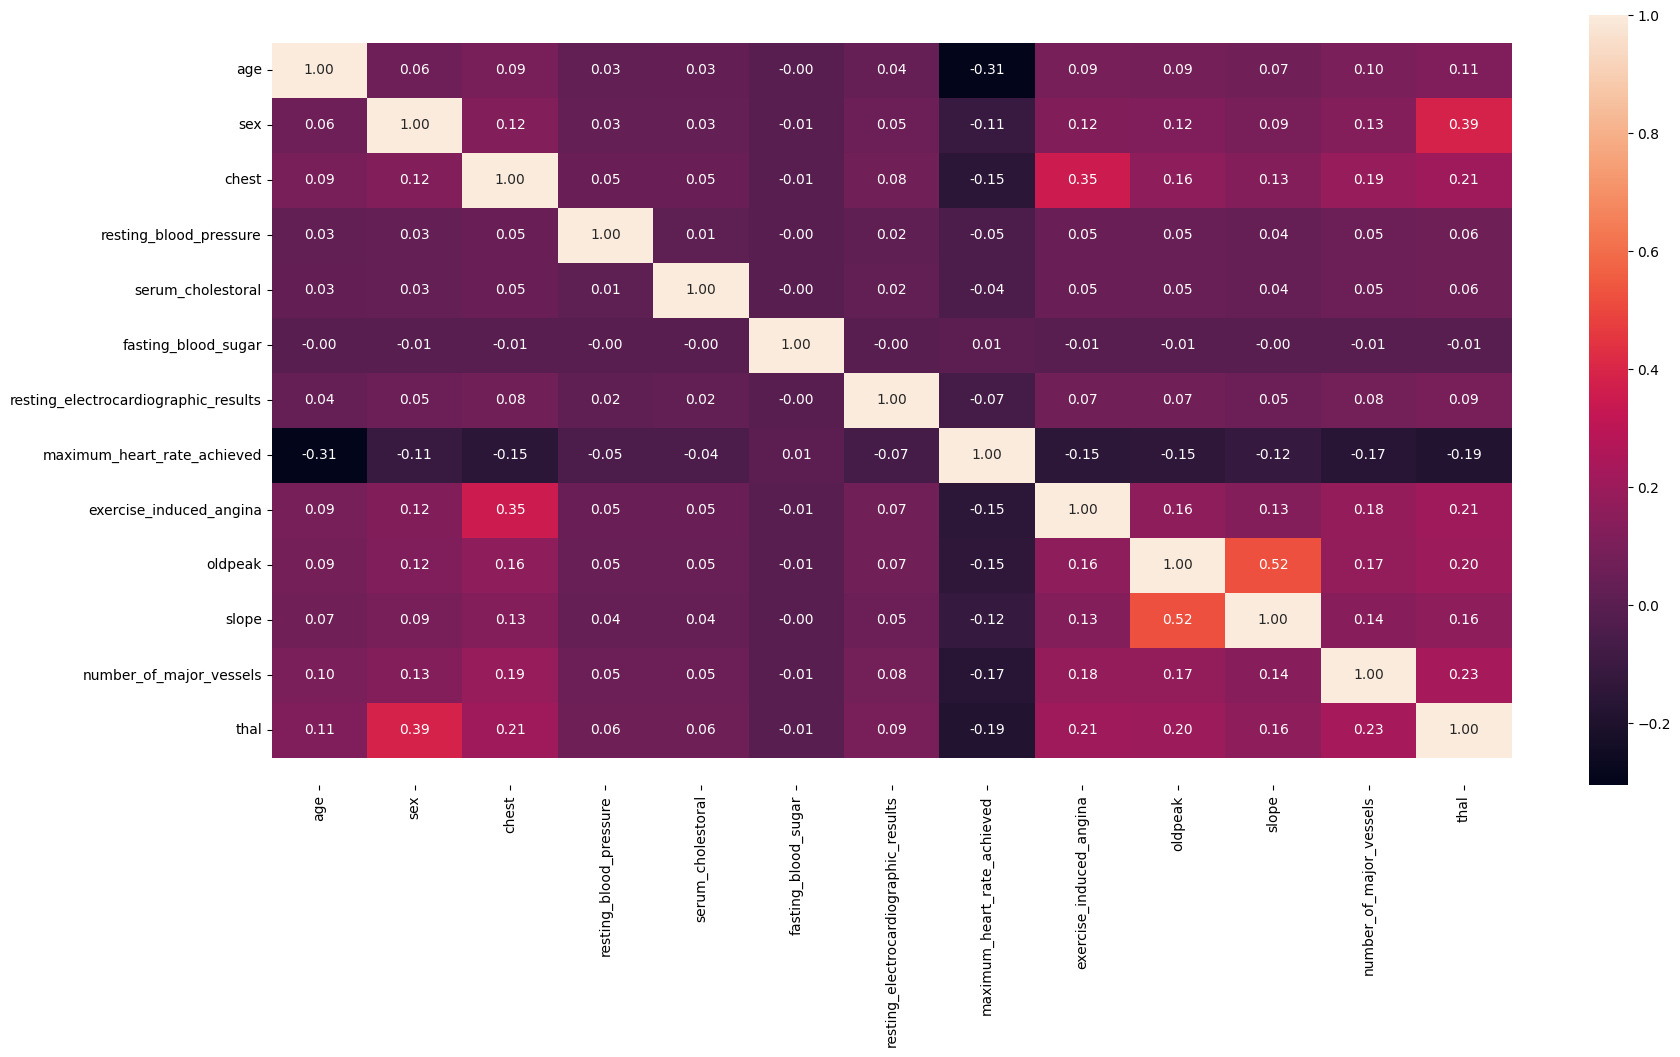

In [27]:
#Удаляем столбец class
cvd_train_corr = cvd_train_corr.drop('class', axis=1)
#Строим тепловую карту по матрице корреляций
plt.figure(figsize = (20,10))
ax=sns.heatmap(cvd_train_corr.corr(), annot = True, fmt = ".2f")
# Получаем текущие границы оси Y
i, k = ax.get_ylim()
# Сужаем диапазон оси Y
ax.set_ylim(i+0.5, k-0.5)

In [28]:
#Ищем значения связи больше 0.8, чтобы исключить мультиколлинеарность
corr = cvd_train_corr.corr(numeric_only=True).round(4)
m = (corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.8).any()
raw = corr.loc[m, m]
raw #таких признаков нет, значит нет мультиколлинеарности

""


(13.5, -0.5)

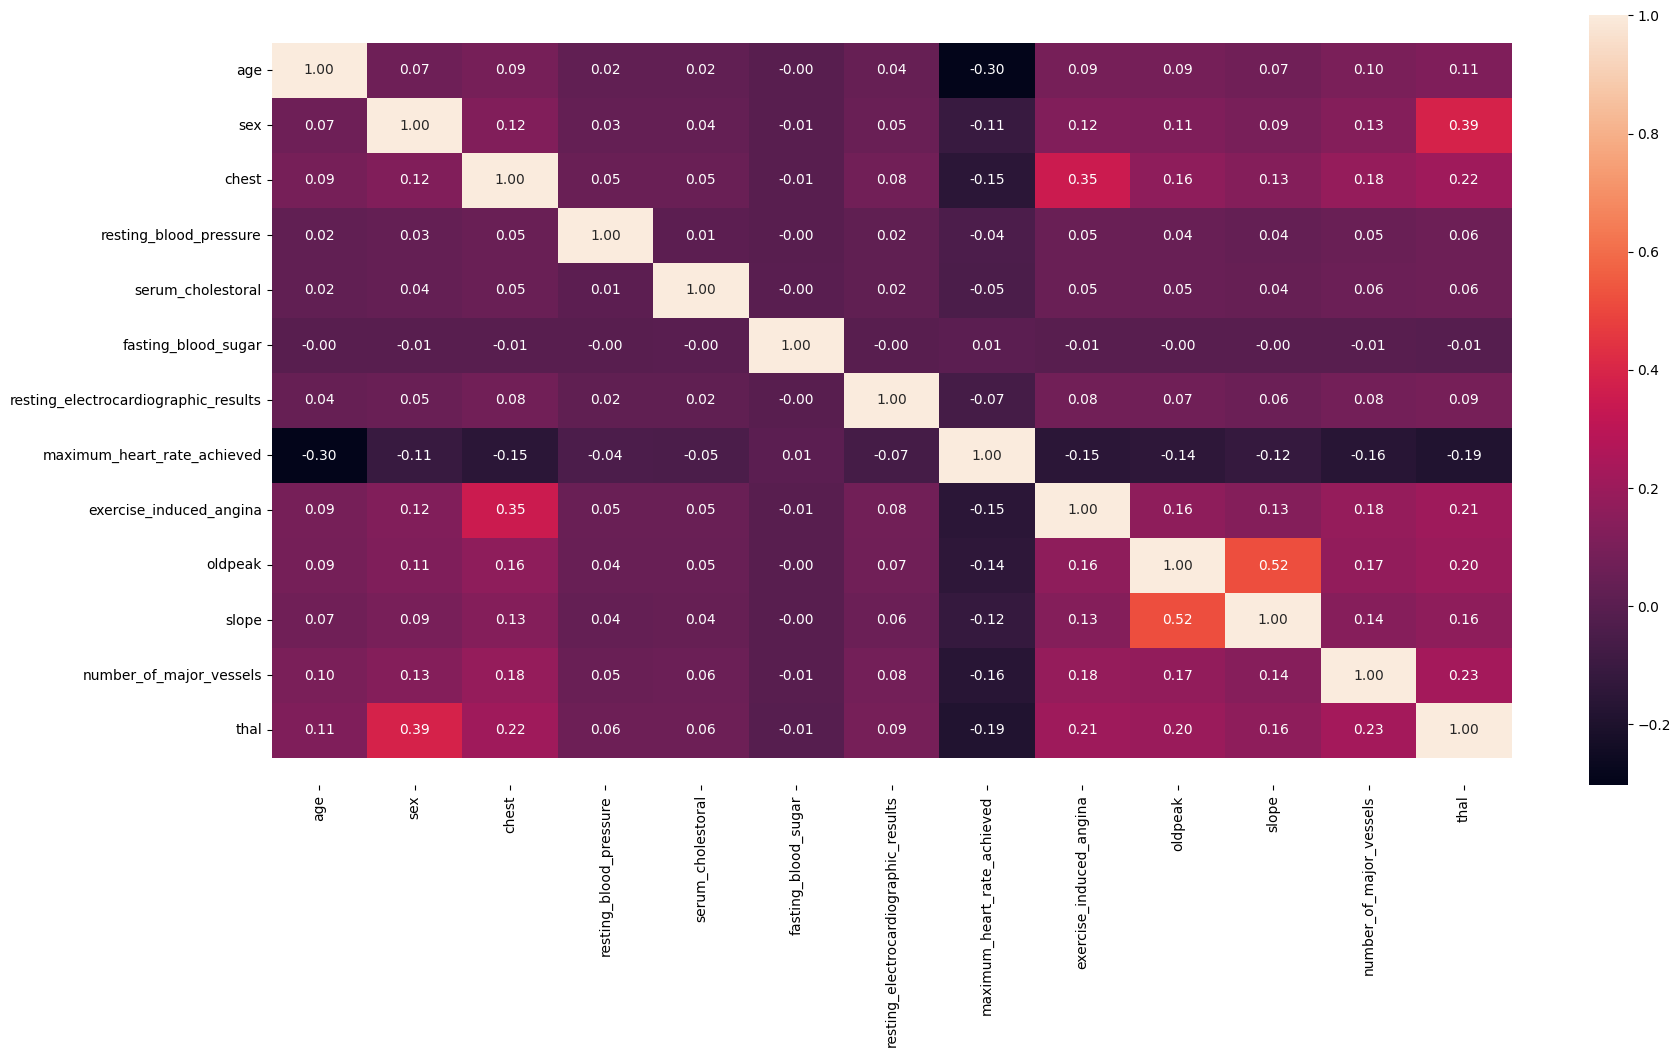

In [29]:
#Удаляем столбец ID
cvd_test_corr = cvd_test_corr.drop('ID', axis=1)
#Строим тепловую карту по матрице корреляций
plt.figure(figsize = (20,10))
ax=sns.heatmap(cvd_test_corr.corr(), annot = True, fmt = ".2f")
# Получаем текущие границы оси Y
i, k = ax.get_ylim()
# Сужаем диапазон оси Y
ax.set_ylim(i+0.5, k-0.5)

In [30]:
#Ищем значения связи больше 0.8, чтобы исключить мультиколлинеарность
corr = cvd_test_corr.corr(numeric_only=True).round(4)
m = (corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.8).any()
raw = corr.loc[m, m]
raw #таких признаков нет, значит нет мультиколлинеарности

""


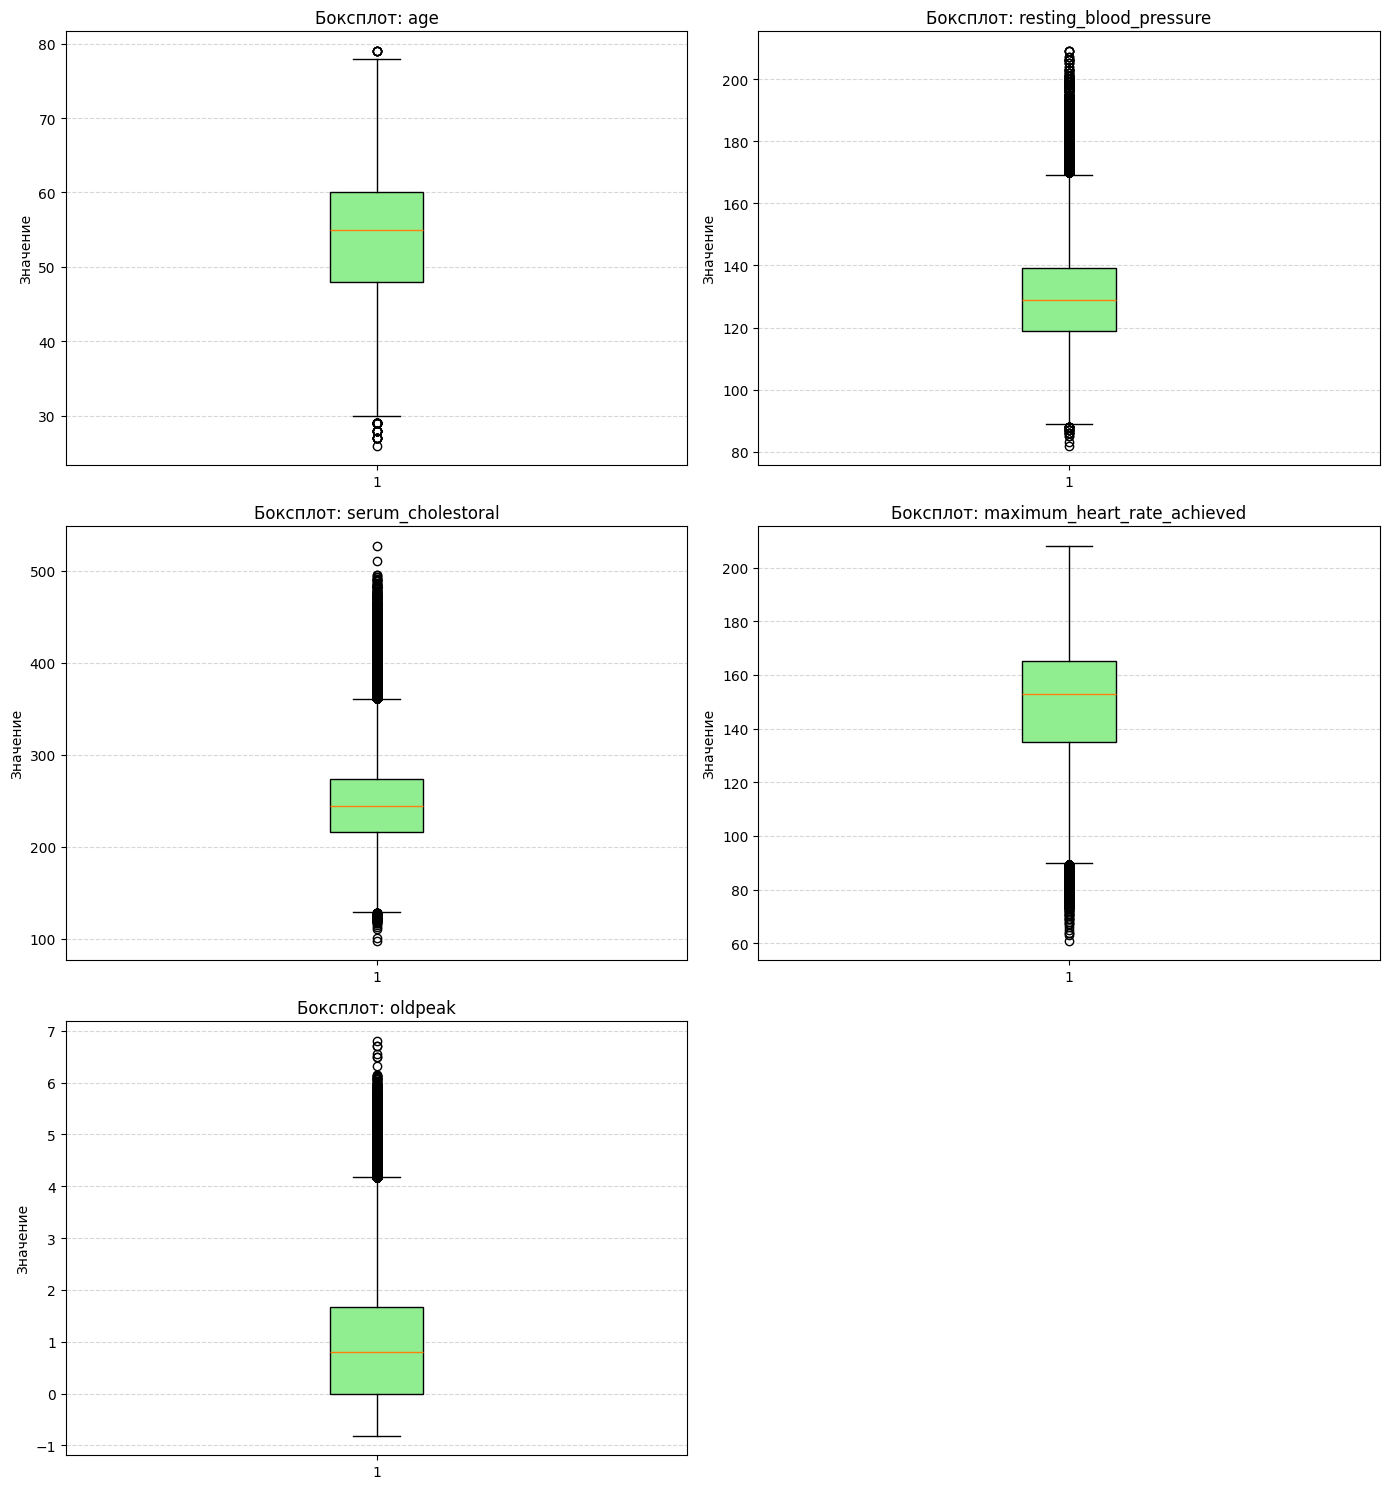

In [31]:
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak']
#Подбираем сетку: 2 колонки, строк — сколько нужно
n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # Превращаем массив осей в плоский список для удобного перебора

for idx, col in enumerate(num_cols):
    ax = axes[idx]

    ax.boxplot(cvd_train_ml[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(f'Боксплот: {col}', fontsize=12)
    ax.set_ylabel('Значение')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#Скрываем пустые сабплоты, если их больше, чем столбцов
for idx in range(len(num_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

#Как правило, выбросы в мед.данных не вляются аномалиями. Так, в столбце age
#выпадающие знаяения - это возраст больше 80 и меньше 30, однако в таком возрасте
#тоже встречаются ССЗ. Аналогично с давлением, давление выше 180, вероятнее всего
#указывает на гипертонию и другие патологии, а ниже 90 и до 80 для многих людей норма.
#Аналогично можно рассуждать с уровнем холестерина и ЧСС. Выбросы в oldpeak,
#вероятнее всего, указыают на наличие ИБС или нестабильной стенокардии.
#Следовательно, все эти значения - диагностические признаки, их нельзя удалять.

## **3.Обучение моделей**

In [32]:
#Выполняем загрузку библиотек
from sklearn.linear_model import LogisticRegression
from sklearn import model_selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn import metrics

In [34]:
#Делим датасет на признаки и ключевую переменную
X = cvd_train_ml.drop(columns=['class'])
y = cvd_train_ml['class']

#Импорт библиотеки для разделения датасета
from sklearn.model_selection import train_test_split

#Делим датасет на тренировочную и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
#Импорт библиотеки для масштабирования
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

In [ ]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

In [ ]:
!pip install optuna

In [ ]:
#Импорт оптуны для подбора гиперпараметров
import optuna
import warnings
warnings.filterwarnings("ignore")

### **3.1. Логистическая регрессия**

In [ ]:
#Подбор гиперпараметров для логистической регрессии
def optuna_lr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'max_iter': 1000,
        'random_state': 42
    }
    model = LogisticRegression(**params)
    model.fit(X_train_sc, y_train)
    score = roc_auc_score(y_train, model.predict(X_train_sc))

    return score

# Запуск оптимизации
study_lr = optuna.create_study(study_name="LogisticRegression", direction="maximize")
study_lr.optimize(optuna_lr, n_trials=30)

print("Наилучшие значения гиперпараметров:", study_lr.best_params)
print("ROC-AUC на обучающем наборе: {:.2f}".format(study_lr.best_value))

#Наилучшие значения гиперпараметров: {'C': 0.0006825541731082067, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced'}
#ROC-AUC на обучающем наборе: 0.88

In [36]:
#Создание и обучение модели ЛР
lg_model = LogisticRegression(
    max_iter=1000,
    C = 0.0006825541731082067,
    penalty = 'l2',
    solver = 'saga',
    class_weight = 'balanced',
    random_state=42
)
lg_model.fit(X_train_sc, y_train)
y_train_pred_lg = lg_model.predict(X_train_sc)
y_pred_val_lg = lg_model.predict(X_val_sc)
y_prob_lg = lg_model.predict_proba(X_val_sc)

In [37]:
#Метрики
print(metrics.classification_report(y_val, y_pred_val_lg))
print('Train accuracy: {:.3f}'.format(accuracy_score(y_train, y_train_pred_lg)))
print('Validation accuracy: {:.3f}'.format(accuracy_score(y_val, y_pred_val_lg)))
print("ROC-AUC: {:.2f}".format(roc_auc_score(y_val, y_prob_lg[:, 1])))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     66698
           1       0.85      0.87      0.86     53302

    accuracy                           0.88    120000
   macro avg       0.87      0.88      0.88    120000
weighted avg       0.88      0.88      0.88    120000

Train accuracy: 0.877
Validation accuracy: 0.876
ROC-AUC: 0.95


In [ ]:
#Модель показала неплохие результаты: качество (ROC-AUC: 0.95), остальные метрики
#имеют высокие показатели (>= 0,85). Разница между Train и Validation accuracy
#небольшая, значит уровень переобучения низкий.

### **3.2. Случайный лес**

In [ ]:
#Подбор гиперпараметров для случайного леса
def optuna_rf(trial):
    # Гиперпараметры для поиска
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'random_state': 42,
        'n_jobs': -1
    }
     # создаем модель
    model = RandomForestClassifier(**params)

    # обучаем модель
    model.fit(X_train, y_train)
    score = roc_auc_score(y_train, model.predict(X_train))

    return score

# cоздаем объект исследования
study_rf = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study_rf.optimize(optuna_rf, n_trials=30)

# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study_rf.best_params))
print("ROC-AUC на обучающем наборе: {:.2f}".format(study_rf.best_value))

# Наилучшие значения гиперпараметров {'n_estimators': 250, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced_subsample'}
# ROC-AUC на обучающем наборе: 0.97

In [38]:
#Создание и обучение модели СЛ
rf_model = RandomForestClassifier(
    n_estimators = 250,
    max_depth = 18,
    min_samples_split = 4,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    bootstrap = False,
    class_weight = 'balanced_subsample',
    random_state=42
    )
#Обучаем модель
rf_model.fit(X_train, y_train)
#Делаем предсказание
y_train_pred_rf = rf_model.predict(X_train)
y_pred_val_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)

In [39]:
#Метрики
print(metrics.classification_report(y_val, y_pred_val_rf))
print('Train accuracy: {:.3f}'.format(accuracy_score(y_train, y_train_pred_rf)))
print('Validation accuracy: {:.3f}'.format(accuracy_score(y_val, y_pred_val_rf)))
print("ROC-AUC: {:.2f}".format(roc_auc_score(y_val, y_prob_rf[:, 1])))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91     66698
           1       0.88      0.88      0.88     53302

    accuracy                           0.90    120000
   macro avg       0.90      0.90      0.90    120000
weighted avg       0.90      0.90      0.90    120000

Train accuracy: 0.969
Validation accuracy: 0.897
ROC-AUC: 0.96


In [ ]:
#У случайного леса наблюдаются хорошие результаты: качество (ROC-AUC: 0.96), между
#Train и Validation выборками многие метрики имеют небольшую разницу, за исключением
#accuracy, где разница почти 0,08. Это говорит о том, что модель все же немного
#переобучилась.
#Стоит отметить, что в целом значения метрик выше, чем у регрессии, но ЛР меньше
#переобучилась!

### **3.3. Кривые обучения ЛР и СЛ**

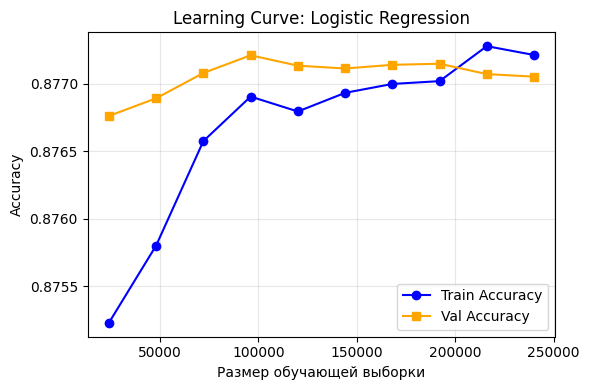

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


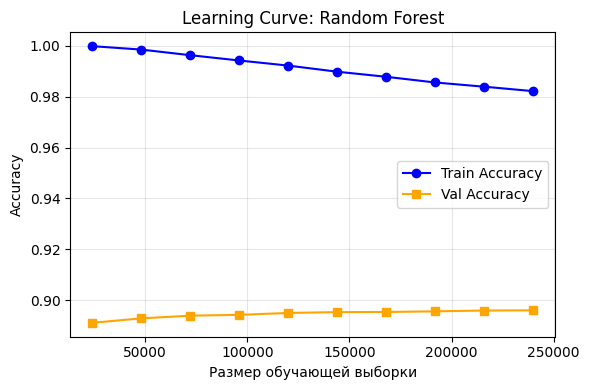

In [40]:
#Строим кривые обучения для ЛР и СЛ
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, cv=2):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_mean, 'o-', label='Train Accuracy', color='blue')
    plt.plot(train_sizes, val_mean, 's-', label='Val Accuracy', color='orange')


    plt.title(f'Learning Curve: {model_name}', fontsize=12)
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Построение для обеих моделей
plot_learning_curve(lg_model, X_train_sc, y_train, 'Logistic Regression')
plot_learning_curve(rf_model, X_train, y_train, 'Random Forest')

In [ ]:
#По графикам видим, что у модели ЛР произошло пересечение тренировочных и
#валидачионных кривых, что говорит о недообучении модели, а у модели СЛ
#графики слишком отдалены друг от друга, что говорит о переобучении.
#Все это произошло даже несмотря на подбор гиперпараметров, однако для
#более точного подбора лучше использовать GridSearch, но параметры для леса он
#подбирает не один час.

### **3.4. Нейронная сеть**

In [41]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.4 MB/s eta 0:00:00


In [42]:
#Импортируем pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [43]:
#Создаем архитектуру нейронной сети
#Наследуемся от базового класса nn.Module
class CVDNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        #Создаем последовательные слои
        self.net = nn.Sequential(
            #полносвязный слой
            nn.Linear(input_dim, 256),
            #нормализует активации
            nn.BatchNorm1d(256),
            #функция активации
            nn.ReLU(),
            #выключение 30% нейронов для борьбы с переобучением
            nn.Dropout(0.3),
            #второй скрытый слой
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            #выходной нейрон для бинарной классификации
            nn.Linear(128, 1)
        )
    #forward определяет, как данные проходят через сеть
    def forward(self, x): return self.net(x)
#Автоматический выбор
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Конвертация данных в тензоры
X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_sc, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

#Связывание признаков и целевой переменной
train_ds = TensorDataset(X_tr_t, y_tr_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
#Разбивка на батчи
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)

#Создание модели
model = CVDNet(input_dim=X_train_sc.shape[1]).to(device)
#Функция потерь
criterion = nn.BCEWithLogitsLoss()
#Оптимизатор Adam для регуляризации
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

#Сохранение истории для графиков обучения
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
#Гиперпараметры для обучения
epochs, patience, best_val_loss, trigger = 15, 3, float('inf'), 0

#Цикл обучения
for epoch in range(epochs):
    #Обучение на тренировочных батчах
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
        preds = (torch.sigmoid(out) >= 0.5).float()
        tr_correct += (preds == yb).sum().item()
        tr_total += xb.size(0)

    #Валидация
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += criterion(out, yb).item() * xb.size(0)
            preds = (torch.sigmoid(out) >= 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)
    #Усреднение метрик
    tr_loss /= tr_total; val_loss /= val_total
    tr_acc = tr_correct / tr_total; val_acc = val_correct / val_total
    #Сохранение метрик в историю для графиков
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    #Сохранение лучшей модели с помощью ранней остановки
    if val_loss < best_val_loss:
        #Если val loss улучшился — сохраняем веса модели
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_nn_model.pth')
        trigger = 0 #сброс счетчика
    else:
        trigger += 1
        if trigger >= patience:
            print("Early Stopping triggered")
            #Прерываем обучение, чтобы не переобучаться
            break


Early Stopping triggered


In [44]:
#Загружаем лучшую версию модели (веса с лучшим val_loss)
model.load_state_dict(torch.load('best_nn_model.pth', weights_only=True))
model.eval() #режим инференса

CVDNet(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [45]:
#Делаем предсказание
with torch.no_grad():
    train_probs = torch.sigmoid(model(X_tr_t.to(device))).cpu().numpy()
    train_preds = (train_probs >= 0.5).astype(int)
    val_probs = torch.sigmoid(model(X_val_t.to(device))).cpu().numpy()
    val_preds = (val_probs >= 0.5).astype(int)

In [48]:
#Смотрим метрики
print(f"ROC-AUC  : {roc_auc_score(y_val, val_probs):.2f}")
print('Train accuracy: {:.3f}'.format(accuracy_score(y_train, train_preds)))
print('Validation accuracy: {:.3f}'.format(accuracy_score(y_val, val_preds)))
print(metrics.classification_report(y_val, val_preds))


ROC-AUC  : 0.96
Train accuracy: 0.898
Validation accuracy: 0.898
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     66698
           1       0.89      0.88      0.88     53302

    accuracy                           0.90    120000
   macro avg       0.90      0.90      0.90    120000
weighted avg       0.90      0.90      0.90    120000



In [ ]:
#У нейронной сети наблюдается отличное качество (ROC-AUC  : 0.96), низкий уровень
#переобучения (разница между валидац. и тренировочной accuracy отсутствует).
#На остальных метриках можно отследить тоже самое (маленькая разница между train и val),
#кроме того они все достаточно высокие, что еще раз подтверждает качесво модели.

### **3.5. График обучения НС**

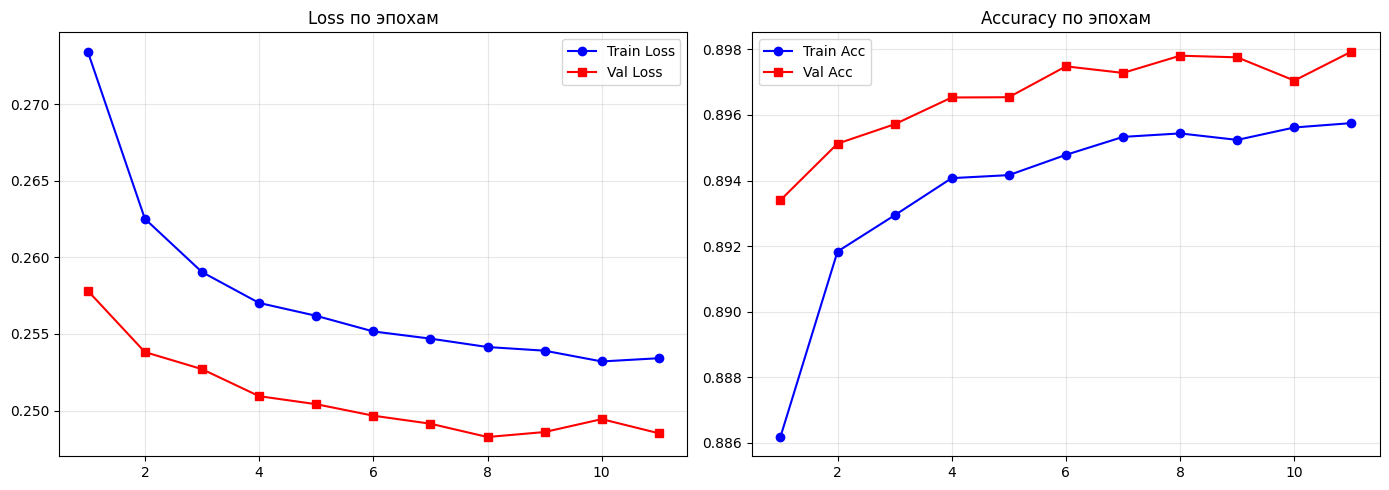

In [47]:
#График обучения нейросети
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss')
axes[0].set_title('Loss по эпохам'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], 'r-s', label='Val Acc')
axes[1].set_title('Accuracy по эпохам'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#По графикам видим, что расстояние между тренировочными и валидационными кривыми
#равномерное и не очень большое, что говорит об отсутствии переобучения и является
#хорошим результатом

# **Общий вывод из анализа моделей:**
**Наилучшие результаты по всем метрикам показала нейронная сеть. У нее так же наблюдается самый низкий уровень переобучения наравне с высокой точностью. Что касается логистической регрессии, модель показала по метрикам неплохие результаты, но график показал, что она недообучилась. Случайный лес имел достаточно высокие результаты по значениям метрик, однако данная модель переобучилась. Возможно в дальнейшем улучшение результатов за счет использования GridSearch для подбора гиперпарамеров.**

In [ ]:
#Сохраняем в инференс
joblib.dump(lg_model, 'lr_model.pkl')

In [ ]:
#Сохраняем в инференс
joblib.dump(rf_model, 'rf_model.pkl')

In [ ]:
#Сохраняем эти файлы для инференса на диске
!cp *.pkl "/content/drive/MyDrive/Глубокое обучение/data/"
!cp *.pth "/content/drive/MyDrive/Глубокое обучение/data/"